# CSCI 5622 HW #4 - Questions (a) and (b)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from transformers import BertTokenizer, BertModel
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
import os

## (a) Data processing

In [2]:
labels_path = r"../Study 1 (EDAIC)/DepressionLabels.csv"
transcripts_path = r"../Study 1 (EDAIC)/EDAIC Transcripts"

# Read depression labels
labels_df = pd.read_csv(labels_path)
labels_df

,Participant_ID,PHQ_Score
0,300,2
1,301,3
2,302,4
3,303,0
4,304,6
...,...,...
214,698,19
215,702,0
216,703,8
217,707,1


### Identify participants for which data is available

In [3]:
# Check that labels provided have a matching transcript
# Disregard participant data where a label/score or transcript are unavailable
ids = list()
transcripts_list = list()
phq_scores = list()
all_scores = labels_df['PHQ_Score'].to_numpy()
for i, id in enumerate(labels_df['Participant_ID'].to_numpy()):
    if os.path.isfile(f'{transcripts_path}/{str(id)}_Transcript.csv'):
        ids.append(id)
        transcripts_list.append(f'{str(id)}_Transcript.csv')
        phq_scores.append(all_scores[i])
print(len(ids))

134


### Gather language features for each transcript

In [4]:
def read_transcript_csv(path):
    with open(path, 'r') as f:
        lines = f.readlines()
    processed_lines = [l.strip() for l in lines[1:]]
    return processed_lines

def compute_transcript_sentiment(lines:list):
    '''
    Code written using Microsoft Copilot
    Calculates average of each sentiment score as given by the Vader sentiment package
    '''
    analyzer = SentimentIntensityAnalyzer()
    scores = [analyzer.polarity_scores(statement) for statement in lines]
    
    # Aggregate by mean
    avg_compound = sum(s['compound'] for s in scores) / len(scores)
    avg_pos = sum(s['pos'] for s in scores) / len(scores)
    avg_neg = sum(s['neg'] for s in scores) / len(scores)
    avg_neu = sum(s['neu'] for s in scores) / len(scores)
    
    return {
        'avg_compound': avg_compound,
        'avg_pos': avg_pos,
        'avg_neg': avg_neg,
        'avg_neu': avg_neu
    }

def get_transcript_embeddings(lines:list):
    '''
    Code written using Microsoft Copilot
    Get average embedding of a transcript using pretrained BERT by mean pooling all statement embeddings 
    '''
    # Define BERT model
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    model = BertModel.from_pretrained('bert-base-uncased')

    embeddings = list()
    for statement in lines: # Get embedding for each statement
        inputs = tokenizer(statement, return_tensors='pt', truncation=True, padding=True)
        with torch.no_grad():
            outputs = model(**inputs)
        # Get [CLS] token embedding (first token)
        cls_embedding = outputs.last_hidden_state[:, 0, :]  # shape: [1, hidden_size]
        embeddings.append(cls_embedding)  

    # Calculate average embedding across all statements
    transcript_embedding = torch.mean(torch.cat(embeddings, dim=0), dim=0)
    return transcript_embedding

#### Extract sentiment scores and BERT embeddings

In [13]:
# Iterate through all relevant CSV files
lang_features = dict()
all_transcripts = list()
for file in transcripts_list:
    # Read transcript and prepare for simple vectorization
    ls = read_transcript_csv(os.path.join(transcripts_path, file))
    all_transcripts.append(ls)
    
    # Get average sentiment scores using Vader
    sentiment_scores = compute_transcript_sentiment(ls)
    
    # Extract average embedding for each transcript using pretrained BERT
    embedding = get_transcript_embeddings(ls).numpy()

    # Store language features based on ID
    id = int(file[:3])
    tmp_features = {"sentiment":sentiment_scores, "embedding":embedding}
    lang_features[id] = tmp_features

#### Get syntactic vector of all transcripts

In [5]:
# Read transcript and prepare for simple vectorization
all_transcripts = list()
for file in transcripts_list:
    ls = read_transcript_csv(os.path.join(transcripts_path, file))
    all_transcripts.append(ls)

# Consolidate transcripts as contiguous lists (documents)
transcripts_concat = [' '.join(t) for t in all_transcripts]

# Vectorize
vectorizer = TfidfVectorizer(min_df=10)  # Reduce sparsity by requiring words appear in at least 10 documents
tfidf_matrix = vectorizer.fit_transform(transcripts_concat)
pure_tfidf_matrix = tfidf_matrix.toarray()
tfidf_features = vectorizer.get_feature_names_out()

In [ ]:
# Combine results with previous language features
for idx, id_ in enumerate(ids):
    # Add to the corresponding dictionary
    lang_features[id_]['tfidf'] = pure_tfidf_matrix[idx]

NameError: name 'lang_features' is not defined

In [60]:
print(pure_tfidf_matrix.shape)

(134, 1005)


#### Combine data rows to save features as CSV

In [61]:
# Copilot assisted code generation
rows = list()
for i, id in enumerate(ids):
    features = lang_features[id]
    row = {'id':id}

    # Add PHQ scores (outcome)
    row['PHQ_Score'] = phq_scores[i]

    # Get sentiments
    for name,score in features['sentiment'].items():
        row[name] = score
    
    # Get embeddings
    for i, val in enumerate(features['embedding']):
        row[f'embed_{i}'] = val
    
    # Get tfidf features
    for i, val in enumerate(features['tfidf']):
        row[f'tfidf_{i}'] = val
    
    rows.append(row)

# Save language features as csv
lang_df = pd.DataFrame(rows)
lang_df.to_csv('edaic_transcript_features.csv', index=False)

## Load language features from CSV

In [6]:
lang_df = pd.read_csv('edaic_transcript_features.csv')

## (b) Estimate depression severity using a decision tree

In [7]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import KFold, train_test_split
from scipy.stats import pearsonr

### Define metrics

Pearson's correlation and absolute relative error (RE)

In [8]:
print(max(lang_df['PHQ_Score']))

22


In [10]:
def calc_re(pred_score, act_score, max_score=24):
    return abs(pred_score - act_score) / max_score

def calc_avg_re(y_preds, y_acts, max_score=24):
    avg_re = 0
    for pred, act in zip(y_preds, y_acts):
        avg_re += calc_re(pred, act)
    return avg_re / len(y_preds)

def calc_tot_re(y_preds, y_acts, max_score=24):
    tot_re = 0
    for pred, act in zip(y_preds, y_acts):
        tot_re += calc_re(pred, act)
    return tot_re

### Split data into 5 folds as instructed

In [11]:
X = lang_df.drop(columns=['id','PHQ_Score'])
y = lang_df['PHQ_Score']

# Split into train and test first
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=59)

# KFold only on training data
kf = KFold(n_splits=4, shuffle=True, random_state=15)

### Train and cross validate decision trees and evaluate predictions

In [12]:
# Microsoft Copilot written decision tree code
best_re_model = None
best_r_model = None
best_re = 1000
best_r = -1

# Cross-validation on training set
for i, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
    X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]

    model = DecisionTreeRegressor(random_state=31)
    model.fit(X_tr, y_tr)

    preds = model.predict(X_val)

    # Pearson correlation
    r, _ = pearsonr(y_val.values, preds)
    print(f"Fold {i+1} Pearson r: {r:.3f}")

    # Average relative error
    avg_re = calc_tot_re(preds, y_val.values)
    print(f"Fold {i+1} Sum of Relative Errors: {avg_re:.3f}\n")

    if avg_re < best_re:
        best_re = avg_re
        best_re_model = model

    if r > best_r:
        best_r = r
        best_r_model = model

# Evaluate tree with best RE
print(f"Best fold RE: {best_re:.3f}")
test_preds = best_re_model.predict(X_test)
test_r_best, _ = pearsonr(y_test.values, test_preds)
test_re = calc_tot_re(test_preds, y_test.values)
print(f"  Test Pearson r: {test_r_best:.3f}")
print(f"  Test RE: {test_re:.3f}")

# Evaluate tree with best r
print(f"Best fold r: {best_r:.3f}")
test_preds = best_r_model.predict(X_test)
test_r, _ = pearsonr(y_test.values, test_preds)
test_re = calc_tot_re(test_preds, y_test.values)
print(f"  Test Pearson r: {test_r:.3f}")
print(f"  Test RE: {test_re:.3f}")

Fold 1 Pearson r: 0.091
Fold 1 Sum of Relative Errors: 7.542

Fold 2 Pearson r: 0.002
Fold 2 Sum of Relative Errors: 8.250

Fold 3 Pearson r: 0.433
Fold 3 Sum of Relative Errors: 5.042

Fold 4 Pearson r: 0.270
Fold 4 Sum of Relative Errors: 4.875

Best fold RE: 4.875
  Test Pearson r: 0.219
  Test RE: 5.375
Best fold r: 0.433
  Test Pearson r: -0.093
  Test RE: 6.792


In [13]:
# Train tree on all training folds as a test
all_train_model = DecisionTreeRegressor(random_state=15)
all_train_model.fit(X_train, y_train)

# Evaluate on test set
test_preds = all_train_model.predict(X_test)
test_r, _ = pearsonr(y_test.values, test_preds)
test_re = calc_tot_re(test_preds, y_test.values)
print("Trained on 4 folds:")
print(f"  Test Pearson r: {test_r:.3f}")
print(f"  Test RE: {test_re:.3f}")

Trained on 4 folds:
  Test Pearson r: 0.133
  Test RE: 5.667


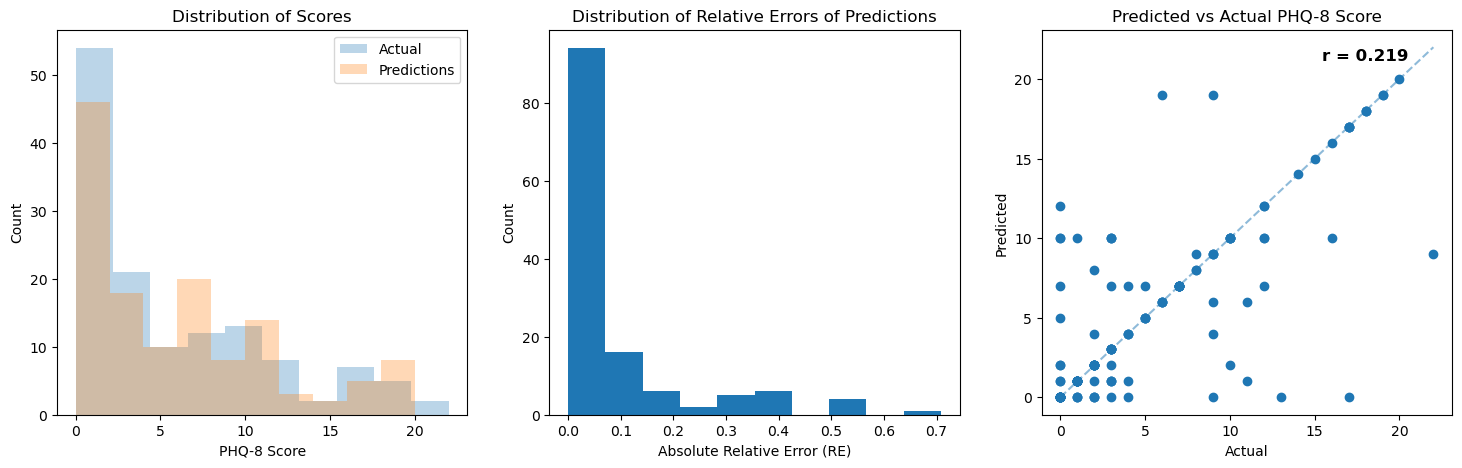

In [14]:
# Plot distribution of relative errors in PHQ-8 among all participants
all_preds = best_re_model.predict(X)
best_re_list = [calc_re(pred, act) for pred, act in zip(all_preds, y.values)]

# Plot hist
fig, axs = plt.subplots(1,3,figsize=(18,5))
axs[0].hist(y.values, alpha=0.3, label="Actual")
axs[0].hist(all_preds, alpha=0.3, label="Predictions")
axs[0].set_xlabel("PHQ-8 Score")
axs[0].set_ylabel("Count")
axs[0].set_title("Distribution of Scores")
axs[0].legend()

axs[1].hist(best_re_list, bins=10)
axs[1].set_xlabel("Absolute Relative Error (RE)")
axs[1].set_ylabel("Count")
axs[1].set_title("Distribution of Relative Errors of Predictions")

axs[2].plot([0,22],[0,22],linestyle='--',alpha=0.5)
axs[2].scatter(y.values, all_preds)
axs[2].text(x=18, y=21, s=f"r = {test_r_best:.3f}", ha='center', va='bottom', fontsize=12, fontweight='bold')
axs[2].set_xlabel("Actual")
axs[2].set_ylabel("Predicted")
axs[2].set_title("Predicted vs Actual PHQ-8 Score")
plt.show()

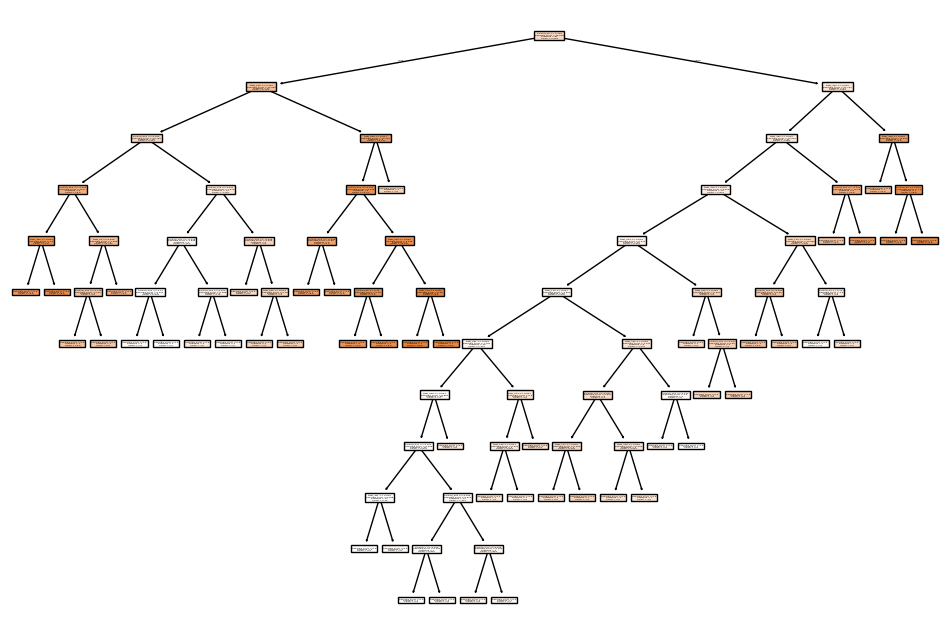

In [15]:
plt.figure(figsize=(12, 8))
plot_tree(best_re_model, feature_names=X.columns, class_names=True, filled=True)
plt.show()

### Perform hyperparameter tuning

#### Pre-pruning

In [16]:
# Define range of max tree sizes
max_depth_values = [5,6,7,8,9,10,11,12,None]  # None = full tree

best_overall_model = None
best_overall_re = float('inf')
best_overall_depth = None

print("Hyperparameter tuning across max_depth values:\n")

for depth in max_depth_values:
    print(f"Testing max_depth = {depth}")
    
    best_re_for_depth = float('inf')
    best_model_for_depth = None
    best_r_for_depth = None
    
    # Cross-validation for this depth
    for i, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]

        model = DecisionTreeRegressor(max_depth=depth, random_state=31)
        model.fit(X_tr, y_tr)

        preds = model.predict(X_val)

        # Pearson correlation
        r, _ = pearsonr(y_val.values, preds)

        # Total relative error
        avg_re = calc_tot_re(preds, y_val.values)

        if avg_re < best_re_for_depth:
            best_re_for_depth = avg_re
            best_model_for_depth = model
            best_r_for_depth = r

    # Print best model metrics for this depth
    print(f"  Best Total RE: {best_re_for_depth:.3f}")
    print(f"  Pearson r for best model: {best_r_for_depth:.3f}\n")

    # Track overall best model
    if best_re_for_depth < best_overall_re:
        best_overall_re = best_re_for_depth
        best_overall_model = best_model_for_depth
        best_overall_depth = depth

# Evaluate best overall model on test set
print(f"Best overall depth: {best_overall_depth}")
test_preds = best_overall_model.predict(X_test)
test_r, _ = pearsonr(y_test.values, test_preds)
test_re = calc_tot_re(test_preds, y_test.values)
print(f"  Test Pearson r: {test_r:.3f}")
print(f"  Test RE: {test_re:.3f}")


Hyperparameter tuning across max_depth values:

Testing max_depth = 5
  Best Total RE: 4.202
  Pearson r for best model: 0.342

Testing max_depth = 6
  Best Total RE: 4.495
  Pearson r for best model: 0.286

Testing max_depth = 7
  Best Total RE: 4.604
  Pearson r for best model: 0.280

Testing max_depth = 8
  Best Total RE: 4.941
  Pearson r for best model: 0.421

Testing max_depth = 9
  Best Total RE: 4.054
  Pearson r for best model: 0.417

Testing max_depth = 10
  Best Total RE: 4.929
  Pearson r for best model: 0.262

Testing max_depth = 11
  Best Total RE: 4.875
  Pearson r for best model: 0.270

Testing max_depth = 12
  Best Total RE: 4.875
  Pearson r for best model: 0.270

Testing max_depth = None
  Best Total RE: 4.875
  Pearson r for best model: 0.270

Best overall depth: 9
  Test Pearson r: 0.203
  Test RE: 5.435


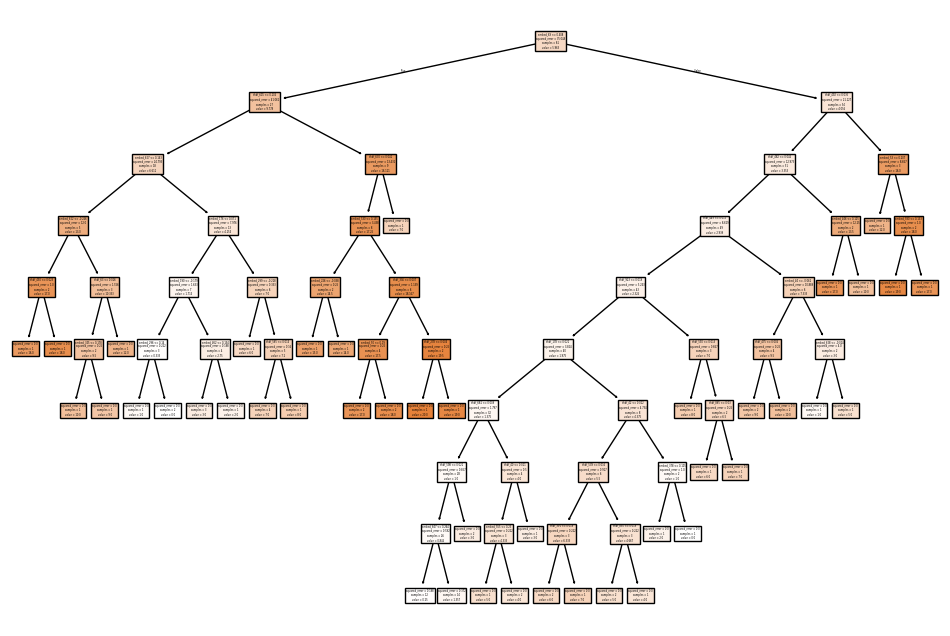

In [17]:
plt.figure(figsize=(12, 8))
plot_tree(best_overall_model, feature_names=X.columns, class_names=True, filled=True)
plt.show()

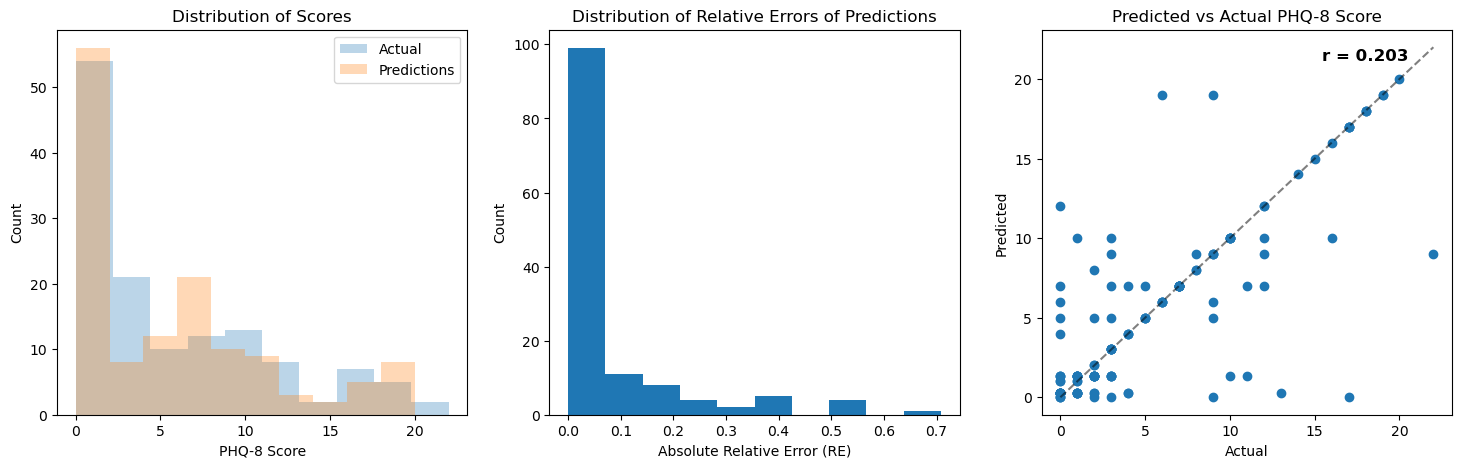

In [18]:
# Plot distribution of relative errors in PHQ-8 among all participants
all_best_preds = best_overall_model.predict(X)
best_overall_re_list = [calc_re(pred, act) for pred, act in zip(all_best_preds, y.values)]

# Visualize data and errors
fig, axs = plt.subplots(1,3,figsize=(18,5))
axs[0].hist(y.values, alpha=0.3, label="Actual")
axs[0].hist(all_best_preds, alpha=0.3, label="Predictions")
axs[0].set_xlabel("PHQ-8 Score")
axs[0].set_ylabel("Count")
axs[0].set_title("Distribution of Scores")
axs[0].legend()

axs[1].hist(best_overall_re_list, bins=10)
axs[1].set_xlabel("Absolute Relative Error (RE)")
axs[1].set_ylabel("Count")
axs[1].set_title("Distribution of Relative Errors of Predictions")

axs[2].plot([0,22],[0,22],linestyle='--',color='k',alpha=0.5)
axs[2].scatter(y.values, all_best_preds)
axs[2].text(x=18, y=21, s=f"r = {test_r:.3f}", ha='center', va='bottom', fontsize=12, fontweight='bold')
axs[2].set_xlabel("Actual")
axs[2].set_ylabel("Predicted")
axs[2].set_title("Predicted vs Actual PHQ-8 Score")
plt.show()

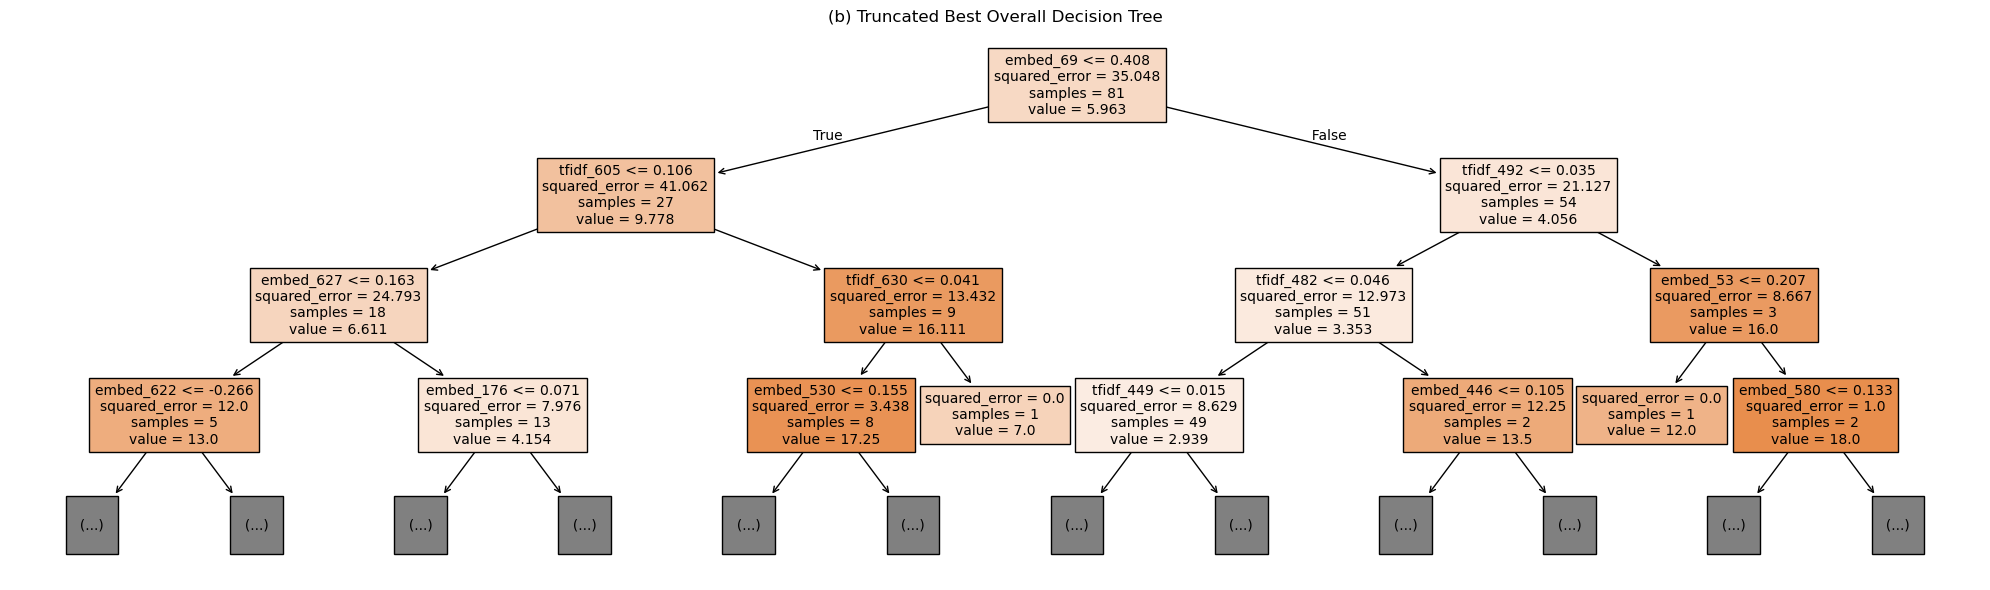

In [19]:
# Examine first 3 levels of tree
plt.figure(figsize=(20, 6))
plot_tree(best_overall_model, feature_names=X.columns, filled=True, class_names=True, max_depth=3, fontsize=10)
plt.title("(b) Truncated Best Overall Decision Tree")
plt.tight_layout()
plt.show()


In [20]:
print("Important TfIDF tokens:")
print(tfidf_features[605])
print(tfidf_features[492])
print(tfidf_features[630])
print(tfidf_features[482])
print(tfidf_features[449])

Important TfIDF tokens:
not
let
other
law
interesting


### Test a highly simplified feature set of only sentiment scores

In [21]:
X_sentiment = lang_df[['avg_compound','avg_pos','avg_neg','avg_neu']]
y = lang_df['PHQ_Score']

# Split into train and test first
X_sentiment_train, X_sentiment_test, y_sentiment_train, y_sentiment_test = train_test_split(X_sentiment, y, test_size=0.2, random_state=21)

# KFold only on training data
kf = KFold(n_splits=4, shuffle=True, random_state=15)

In [22]:
# Microsoft Copilot written decision tree code
best_sen_re_model = None
best_sen_r_model = None
best_re = 1000
best_r = -1

# Cross-validation on training set
for i, (train_idx, val_idx) in enumerate(kf.split(X_sentiment_train)):
    X_tr, y_tr = X_sentiment_train.iloc[train_idx], y_sentiment_train.iloc[train_idx]
    X_val, y_val = X_sentiment_train.iloc[val_idx], y_sentiment_train.iloc[val_idx]

    model = DecisionTreeRegressor(random_state=31)
    model.fit(X_tr, y_tr)

    preds = model.predict(X_val)

    # Pearson correlation
    r, _ = pearsonr(y_val.values, preds)
    print(f"Fold {i+1} Pearson r: {r:.3f}")

    # Average relative error
    avg_re = calc_tot_re(preds, y_val.values)
    print(f"Fold {i+1} Sum of Relative Errors: {avg_re:.3f}\n")

    if avg_re < best_re:
        best_re = avg_re
        best_sen_re_model = model

    if r > best_r:
        best_r = r
        best_sen_r_model = model

# Evaluate tree with best RE
print(f"Best fold RE: {best_re:.3f}")
test_preds = best_sen_re_model.predict(X_sentiment_test)
test_r, _ = pearsonr(y_sentiment_test.values, test_preds)
test_re = calc_tot_re(test_preds, y_sentiment_test.values)
print(f"  Test Pearson r: {test_r:.3f}")
print(f"  Test RE: {test_re:.3f}")

# Evaluate tree with best r
print(f"Best fold r: {best_r:.3f}")
test_preds = best_sen_r_model.predict(X_sentiment_test)
test_r, _ = pearsonr(y_sentiment_test.values, test_preds)
test_re = calc_tot_re(test_preds, y_sentiment_test.values)
print(f"  Test Pearson r: {test_r:.3f}")
print(f"  Test RE: {test_re:.3f}")

Fold 1 Pearson r: 0.006
Fold 1 Sum of Relative Errors: 7.292

Fold 2 Pearson r: -0.043
Fold 2 Sum of Relative Errors: 5.417

Fold 3 Pearson r: -0.280
Fold 3 Sum of Relative Errors: 6.958

Fold 4 Pearson r: 0.157
Fold 4 Sum of Relative Errors: 4.792

Best fold RE: 4.792
  Test Pearson r: -0.006
  Test RE: 6.500
Best fold r: 0.157
  Test Pearson r: -0.006
  Test RE: 6.500


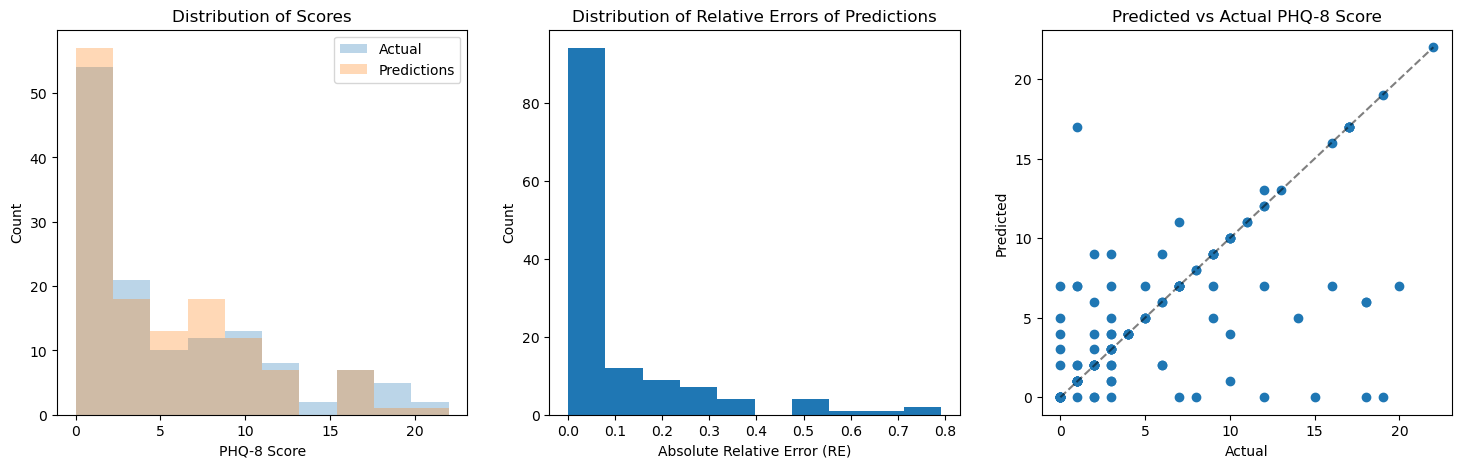

In [23]:
# Plot distribution of relative errors in PHQ-8 among all participants
all_sen_preds = best_sen_re_model.predict(X_sentiment)
best_sen_re_list = [calc_re(pred, act) for pred, act in zip(all_sen_preds, y.values)]

# Visualize data and errors
fig, axs = plt.subplots(1,3,figsize=(18,5))
axs[0].hist(y.values, alpha=0.3, label="Actual")
axs[0].hist(all_sen_preds, alpha=0.3, label="Predictions")
axs[0].set_xlabel("PHQ-8 Score")
axs[0].set_ylabel("Count")
axs[0].set_title("Distribution of Scores")
axs[0].legend()

axs[1].hist(best_sen_re_list, bins=10)
axs[1].set_xlabel("Absolute Relative Error (RE)")
axs[1].set_ylabel("Count")
axs[1].set_title("Distribution of Relative Errors of Predictions")

axs[2].plot([0,22],[0,22],linestyle='--',color='k',alpha=0.5)
axs[2].scatter(y.values, all_sen_preds)
axs[2].set_xlabel("Actual")
axs[2].set_ylabel("Predicted")
axs[2].set_title("Predicted vs Actual PHQ-8 Score")
plt.show()

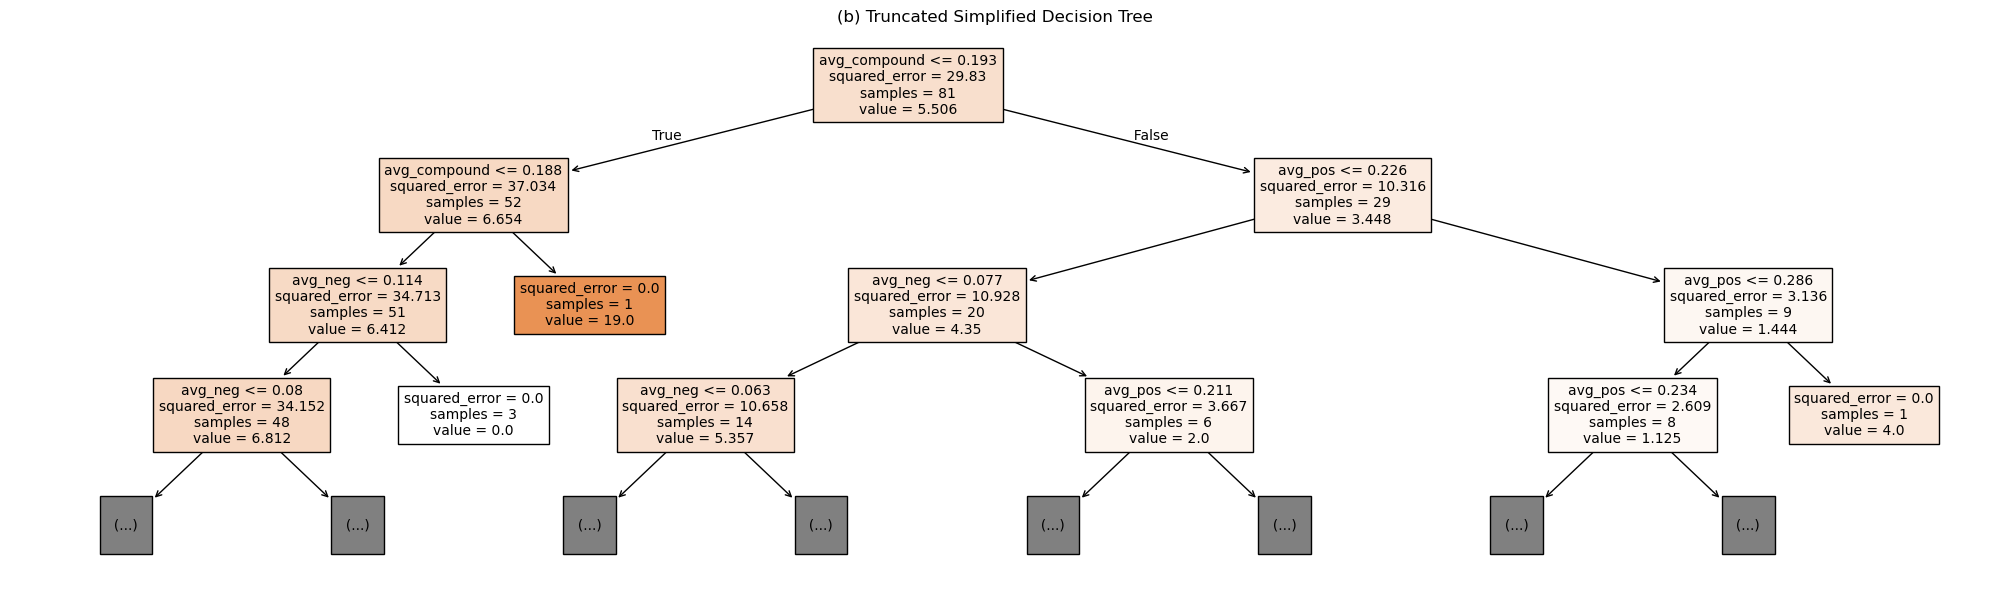

In [24]:
# Plot simplified model
plt.figure(figsize=(20, 6))
plot_tree(best_sen_re_model, feature_names=X_sentiment.columns, filled=True, class_names=True, max_depth=3, fontsize=10)
plt.title("(b) Truncated Simplified Decision Tree")
plt.tight_layout()
plt.show()